In [1]:
import pandas as pd

# Load the cleaned dataset we saved in Phase 4
df = pd.read_csv(r'D:\twitter-sentiment-analyzer\data\cleaned_tweets.csv')

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nSample:")
print(df[['cleaned_text', 'target']].head(3))
print("\nSentiment counts:")
print(df['target'].value_counts())

Data loaded successfully!
Shape: (198790, 3)

Sample:
                                        cleaned_text  target
0                                          ahhh hope       0
1                               cool tweet apps razr       0
2  know family drama lamehey next time hang kim g...       0

Sentiment counts:
target
1    99487
0    99303
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['target']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining sentiment balance:")
print(y_train.value_counts())

Training samples: 159032
Testing samples: 39758

Training sentiment balance:
target
1    79590
0    79442
Name: count, dtype: int64


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion done!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF conversion done!
Training matrix shape: (159032, 50000)
Testing matrix shape: (39758, 50000)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(max_iter=1000)
}

results = {}

for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"✅ {name}: {acc*100:.2f}% accuracy\n")

print("=" * 40)
best = max(results, key=results.get)
print(f"🏆 Best Model: {best} ({results[best]*100:.2f}%)")

Training Logistic Regression...
✅ Logistic Regression: 78.15% accuracy

Training Naive Bayes...
✅ Naive Bayes: 75.92% accuracy

Training Linear SVM...
✅ Linear SVM: 76.36% accuracy

🏆 Best Model: Logistic Regression (78.15%)


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78     19861
    Positive       0.77      0.80      0.79     19897

    accuracy                           0.78     39758
   macro avg       0.78      0.78      0.78     39758
weighted avg       0.78      0.78      0.78     39758



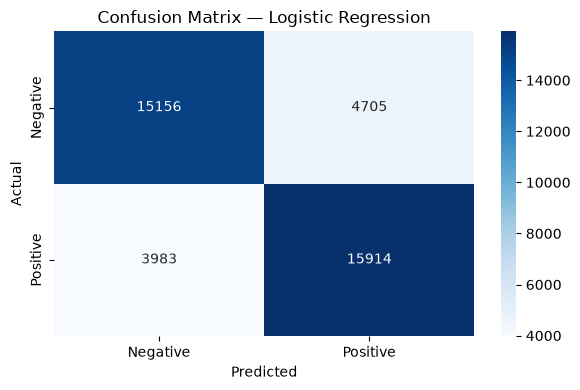

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from best model
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test_tfidf)

# Detailed report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [6]:
import pickle

# Save best model and vectorizer
pickle.dump(best_model, open(r'D:\twitter-sentiment-analyzer\model\sentiment_model.pkl', 'wb'))
pickle.dump(tfidf, open(r'D:\twitter-sentiment-analyzer\model\tfidf_vectorizer.pkl', 'wb'))

print("✅ Model saved!")
print("✅ Vectorizer saved!")

✅ Model saved!
✅ Vectorizer saved!
